In [1]:
import sys
import pathlib

# Get project root (parent of generation/)
project_root = pathlib.Path().resolve().parent
sys.path.insert(0, str(project_root))

### MANIFESTO

In [2]:
from scripts.utils.logger import logger

In [3]:
logger_params = {
    "main_folder": "/home/think/Desktop/MOCK",
    "experiment_name": "Consolidation",
    "date": "2025-09-07",
    "iteration": 69,
    "description": (
        "Se va a consolidar la funcion generadora "
        " de sistemas caoticos, esta sera modular."
        "Es decir, vamos a hacerlo solo para Lorenz con la posibilidad de solo tener"
        "que cambiar la defincion al principio"
        "con dos modos de generacion"
        "- Mismos params, diferentes i.c."
        "- Diferentes params, mismas i.c"
    )
}

In [4]:
exp_folder, manifesto_path = logger(logger_params)
print(f"Experiment folder created at: {exp_folder}")
print(f"Manifesto written to: {manifesto_path}")

Experiment folder created at: /home/think/Desktop/MOCK/Consolidation_2025-09-07_iter69
Manifesto written to: /home/think/Desktop/MOCK/Consolidation_2025-09-07_iter69/manifesto.txt


### LORENZ63

In [5]:
from scripts.data_generation.binder import Binder
from scripts.utils.plastic_surgeon import from_sol_to_df

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [75]:
model_name = 'lorenz63'

sigma = 10 
beta = 8/3
rho = 28
params = (sigma, beta, rho)


In [76]:
binder = Binder("scripts.systems.lorenz63", "lorenz63", params)
binder.import_module()      # will reload if module is already in memory
model_fixed = binder.fixer()

In [77]:
t_span = (0, 105)
t_eval = np.linspace(t_span[0], t_span[1], 10000)
y0 = np.array([0.1, 0.1, 0.1])
# [0.1, 0.1, 0.1]

In [78]:
from scripts.data_generation.tsdg import DynamicalSystem

In [79]:
ds1 = DynamicalSystem(model_fixed, y0, t_eval, notebook = True)

In [80]:
# Step 1: integrate the ODEs
_ = ds1.solve()

### Lyapunov

In [104]:
# Solve perturbed system (tiny difference in y0)
eps = 1e-8
y0_perturbed = y0 + eps
ds2 = DynamicalSystem(model_fixed, y0_perturbed, t_eval, notebook=True)
_ = ds2.solve()

In [105]:
# --- Step 1: compute divergence (distance between trajectories) ---
delta = np.linalg.norm(ds1.solution.y - ds2.solution.y, axis=0)
delta0 = delta[0]  # initial separation

In [106]:
# --- Step 2: estimate maximal Lyapunov exponent ---
# λ ≈ (1/t) * ln(δ(t)/δ0)
lyapunov = np.log(delta / delta0) / t_eval
max_lyapunov = np.mean(lyapunov[-2000:])  # average over last part to reduce fluctuations

/tmp/ipykernel_32459/788732088.py:3: RuntimeWarning: invalid value encountered in divide
  lyapunov = np.log(delta / delta0) / t_eval


In [107]:
print(f"Estimated maximal Lyapunov exponent: {max_lyapunov:.4f}")

Estimated maximal Lyapunov exponent: 0.4736


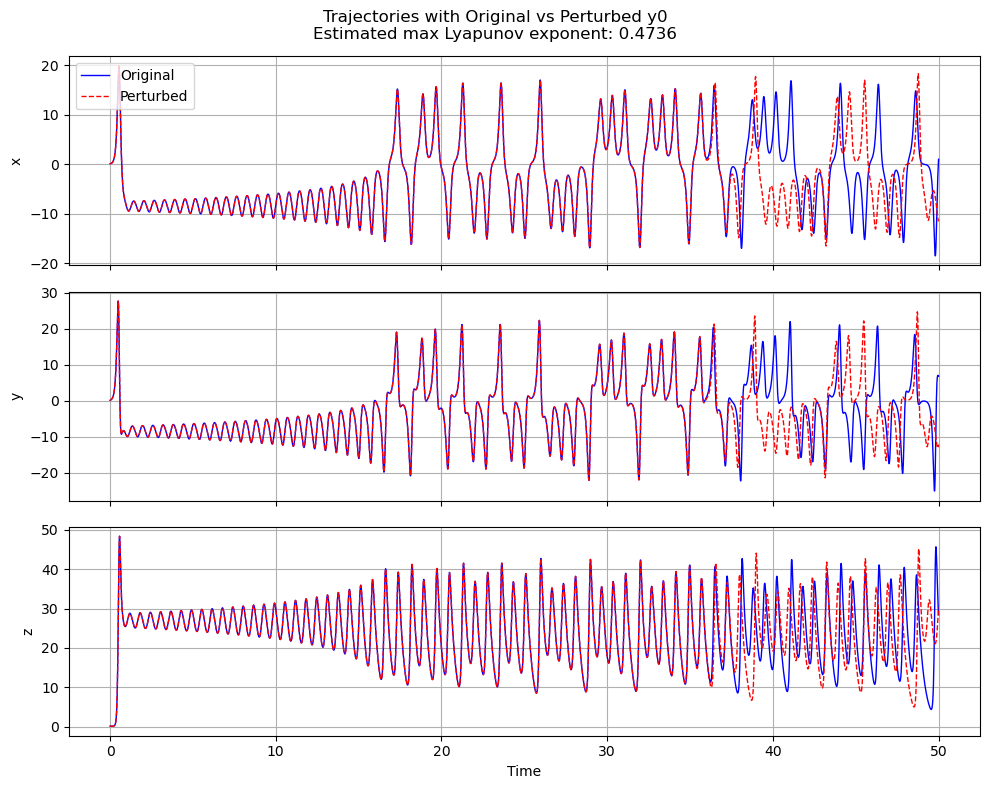

In [108]:
# --- Step 3: plot the three time series for both systems ---
labels = ["x", "y", "z"]

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for i in range(3):
    axs[i].plot(t_eval, ds1.solution.y[i], color="blue", lw=1, label="Original")      # original = blue
    axs[i].plot(t_eval, ds2.solution.y[i], color="red", lw=1, linestyle="--", label="Perturbed")  # perturbed = red
    axs[i].set_ylabel(labels[i])
    axs[i].grid()

axs[-1].set_xlabel("Time")
axs[0].legend()
fig.suptitle(f"Trajectories with Original vs Perturbed y0\nEstimated max Lyapunov exponent: {max_lyapunov:.4f}")
plt.tight_layout()
plt.show()


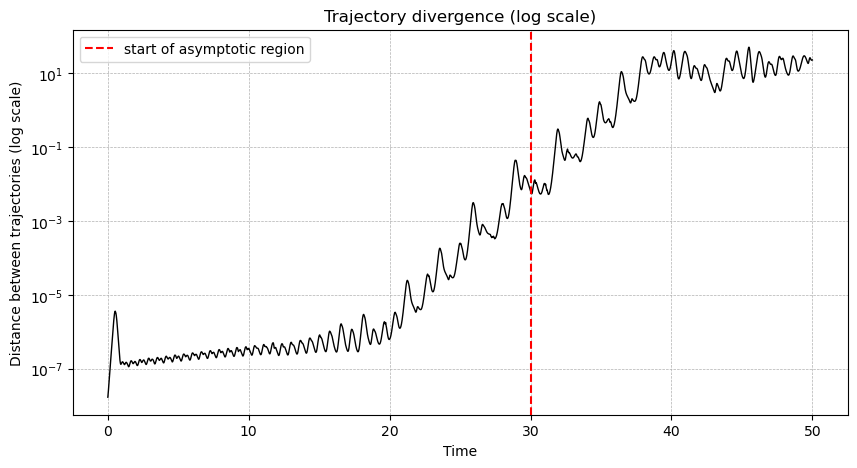

In [109]:
import matplotlib.pyplot as plt

# --- Compute divergence between trajectories ---
delta = np.linalg.norm(ds1.solution.y - ds2.solution.y, axis=0)

# --- Plot the divergence ---
plt.figure(figsize=(10, 5))
plt.plot(t_eval, delta, color="black", lw=1)
plt.yscale("log")  # log scale to see exponential growth as a straight line
plt.xlabel("Time")
plt.ylabel("Distance between trajectories (log scale)")
plt.title("Trajectory divergence (log scale)")

# Optional: highlight the region used for Lyapunov estimation
plt.axvline(t_eval[-2000], color="red", linestyle="--", label="start of asymptotic region")
plt.legend()
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()


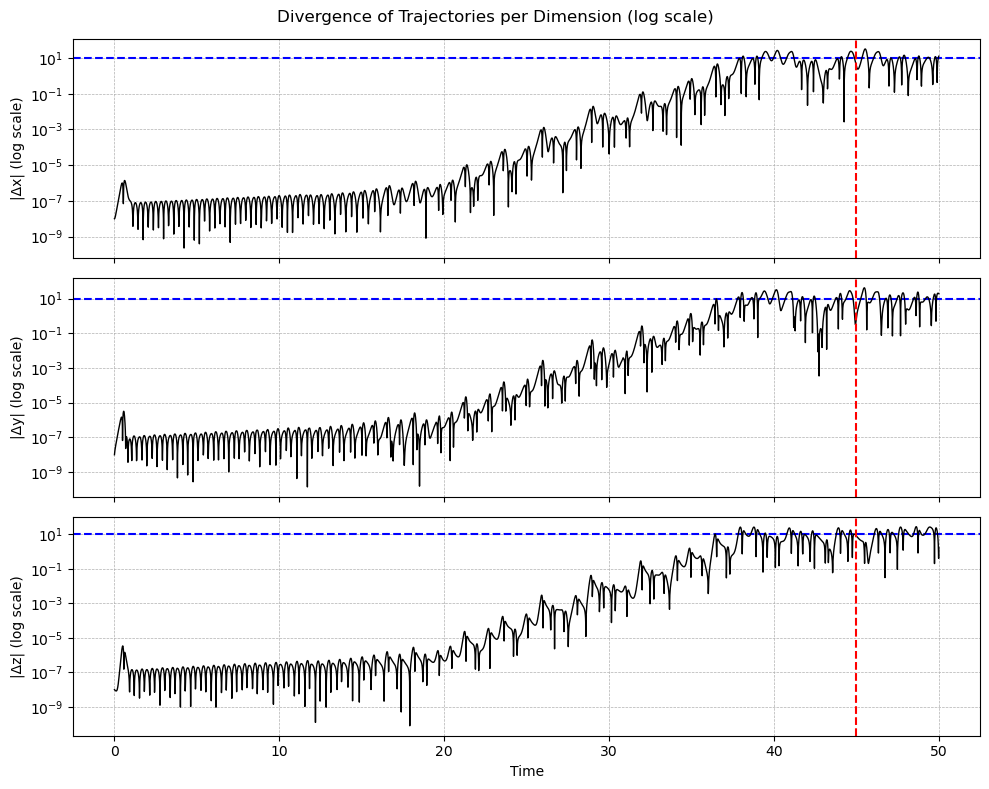

Estimated maximal Lyapunov exponents per dimension:
λ_x = 0.4245, λ_y = 0.4282, λ_z = 0.4307


In [110]:
import numpy as np
import matplotlib.pyplot as plt

# --- Step 0: Solve two trajectories ---
y0 = np.array([0.1, 0.1, 0.1])
t_eval = np.linspace(0, 50, 5000)
eps = 1e-8

ds1 = DynamicalSystem(model_fixed, y0, t_eval, notebook=True)
ds1.solve()

ds2 = DynamicalSystem(model_fixed, y0 + eps, t_eval, notebook=True)
ds2.solve()

# --- Step 1: Compute divergence for each dimension ---
delta_x = np.abs(ds1.solution.y[0] - ds2.solution.y[0])
delta_y = np.abs(ds1.solution.y[1] - ds2.solution.y[1])
delta_z = np.abs(ds1.solution.y[2] - ds2.solution.y[2])


cutoff = -500

# --- Step 2: Plot divergence for each dimension on log scale ---
labels = ["x", "y", "z"]
deltas = [delta_x, delta_y, delta_z]

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

for i in range(3):

    axs[i].axhline(10, color="blue", linestyle="--")  # example "zero" line for log-scale

    axs[i].plot(t_eval, deltas[i], color="black", lw=1)
    axs[i].set_yscale("log")
    axs[i].set_ylabel(f"|Δ{labels[i]}| (log scale)")
    axs[i].grid(True, which="both", ls="--", lw=0.5)
    # highlight last 1000 points used for Lyapunov estimation
    axs[i].axvline(t_eval[cutoff], color="red", linestyle="--")

axs[-1].set_xlabel("Time")
fig.suptitle("Divergence of Trajectories per Dimension (log scale)")
plt.tight_layout()
plt.show()

# --- Step 3: Compute maximal Lyapunov exponent per dimension ---
lambda_x = np.mean(np.log(delta_x[cutoff:] / delta_x[0]) / t_eval[cutoff:])
lambda_y = np.mean(np.log(delta_y[cutoff:] / delta_y[0]) / t_eval[cutoff:])
lambda_z = np.mean(np.log(delta_z[cutoff:] / delta_z[0]) / t_eval[cutoff:])

print(f"Estimated maximal Lyapunov exponents per dimension:")
print(f"λ_x = {lambda_x:.4f}, λ_y = {lambda_y:.4f}, λ_z = {lambda_z:.4f}")


### Visualization

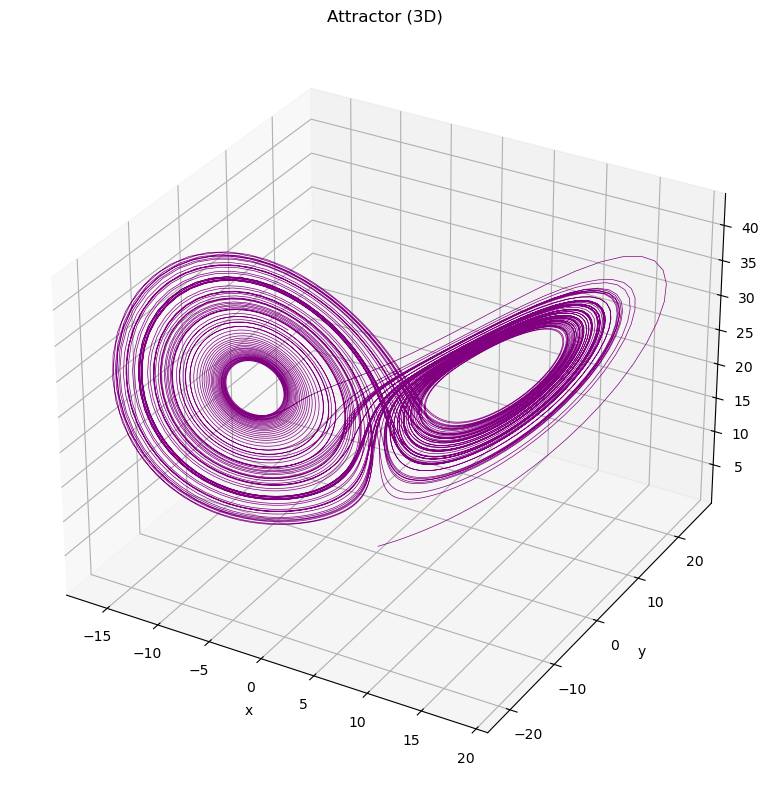

In [73]:
_ = ds.plot(kind="3d")

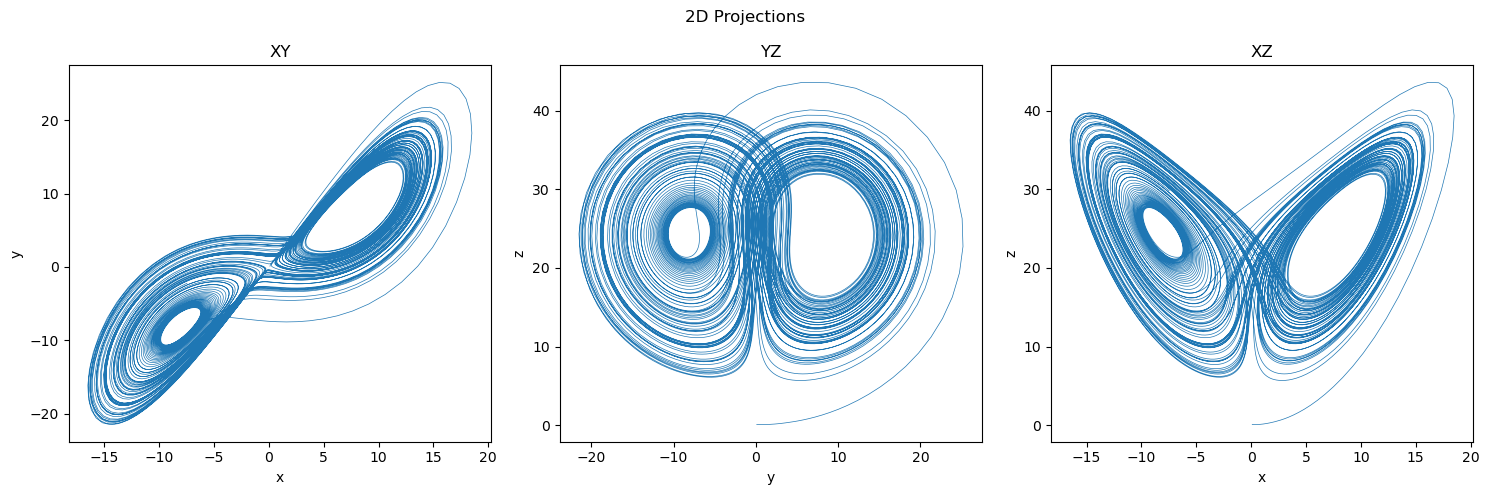

In [74]:
# All projections
_ = ds.plot("projections")

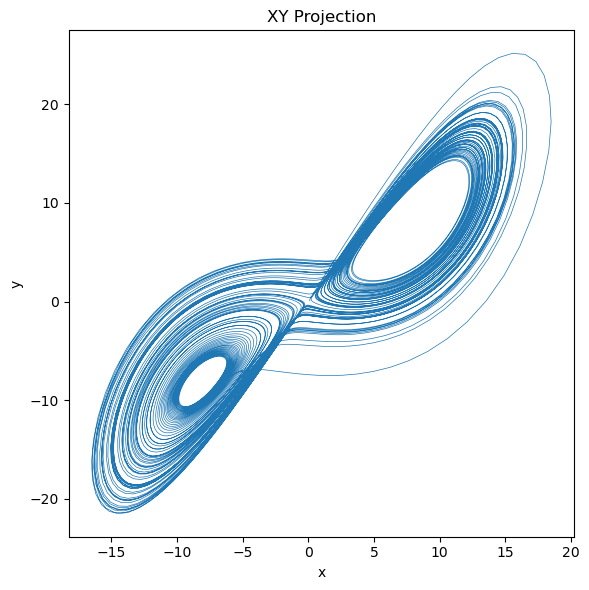

In [15]:
# Just XY projection
_ = ds.plot("projections", variable="xy")

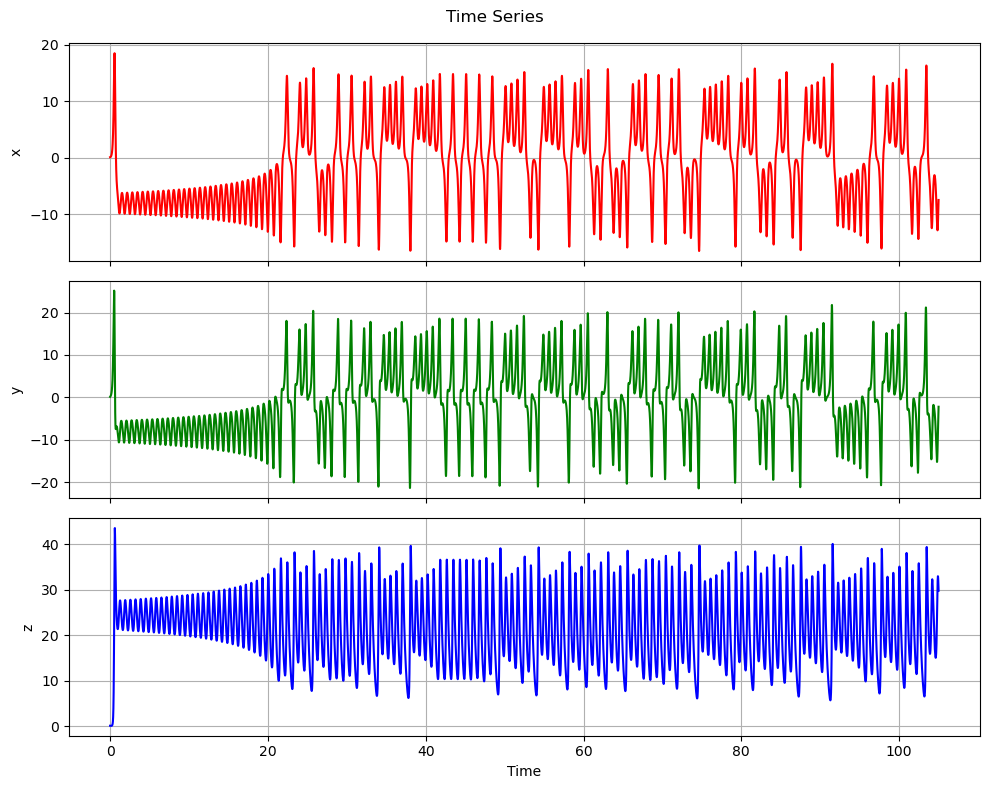

In [16]:
# All time series
_ = ds.plot("series")

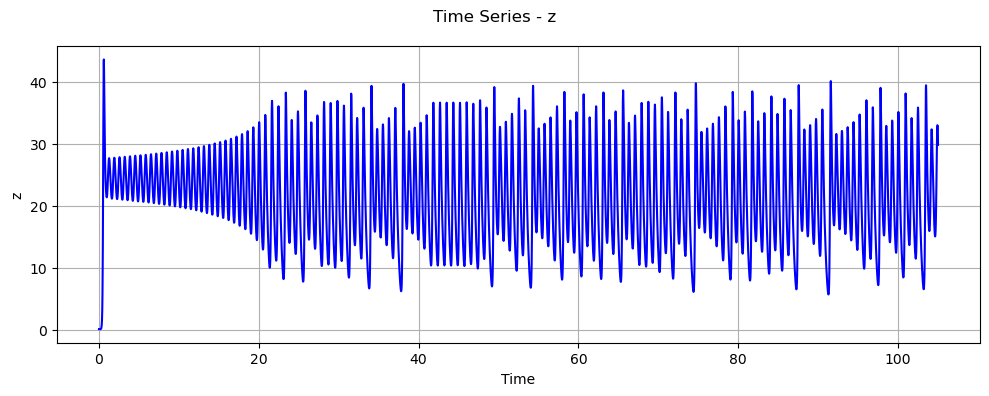

In [17]:
# Only z time series
_ = ds.plot("series", variable="z")

### Data

In [18]:
df = ds.to_dataframe()  # does not save by default
df.head()               # inspect the first few rows

,x,y,z
1,0.100000,0.100000,0.100000
2,0.101292,0.125614,0.097356
3,0.105028,0.151629,0.094815
4,0.111041,0.178660,0.092382
5,0.119216,0.207309,0.090061


In [19]:
#df.to_csv("my_timeseries.csv", index=False)  # save manually later